# Exercise: Snowflake Fundamentals

This notebook covers the Snowflake Fundamentals exercise, enhancing data transformation and performance optimization.

## 1. Load the orders CSV and reviews JSON into Pandas

Use `pd.read_csv()` for `02-Snowflake-Fundamentals-Exercise-Resources/large_orders.csv` and `pd.read_json()` for `02-Snowflake-Fundamentals-Exercise-Resources/large_customer_reviews.json`. The reviews file has a nested `review_data` field — flatten it with `pd.json_normalize()` to get `rating`, `comment`, and `verified` as top-level columns.

In [28]:
# %pip install --upgrade pandas s3fs boto3 botocore
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv(override=True)

# --- AWS credentials ---
AWS_ACCESS_KEY = os.getenv("AWS_ACCESS_KEY")
AWS_SECRET_KEY = os.getenv("AWS_SECRET_KEY")

orders_df = pd.read_csv(
    "s3://engineering-course-9/DataWarehouseAndSnowflake/large_orders.csv",
    storage_options={
        "key": AWS_ACCESS_KEY,
        "secret": AWS_SECRET_KEY,
        "client_kwargs": {"region_name": "eu-north-1"}
    }
)
print(orders_df)
print(
    "-----------------------------------------------------------------------------------------------------------------------------------")
review_raw_df = pd.read_json(
    "s3://engineering-course-9/DataWarehouseAndSnowflake/large_customer_reviews.json",
    storage_options={
        "key": AWS_ACCESS_KEY,
        "secret": AWS_SECRET_KEY,
        "client_kwargs": {"region_name": "eu-north-1"}
    }
)
print(review_raw_df)
print(
    "-----------------------------------------------------------------------------------------------------------------------------------")
reviews_df = pd.concat(
    [review_raw_df.drop(columns=["review_data"]),
     pd.json_normalize(review_raw_df["review_data"])],
    axis=1
)
print(reviews_df)

      order_id customer_id product_id  order_date   amount  profit  quantity  \
0           O1       C2701       P834  2022-10-12  1523.60  187.07         5   
1           O2       C6023       P426  2024-12-26   571.26  258.85         5   
2           O3       C5910       P922  2024-01-23   161.56  198.51        10   
3           O4       C1137       P173  2021-04-23   509.63  493.60         8   
4           O5       C8510       P426  2024-07-09  1964.52  433.47         2   
...        ...         ...        ...         ...      ...     ...       ...   
99995   O99996       C9945       P567  2020-01-28  1098.82  433.44         4   
99996   O99997       C6384       P681  2021-04-30  1000.42  447.88         6   
99997   O99998       C9993       P728  2023-03-21   199.37    8.22         2   
99998   O99999       C2477       P301  2023-12-31   187.60  348.20        10   
99999  O100000       C1768       P986  2023-02-02  1008.49  119.88         4   

              category  subcategory  
0

## 2. Inspect the shape and structure of both DataFrames

Use `shape`, `info()`, `head()`, and `dtypes` to confirm row counts, column types, and identify any missing values before transformation.

In [29]:
print(orders_df.shape)
print(review_raw_df.shape)
print(
    "-----------------------------------------------------------------------------------------------------------------------------------")
print(orders_df.head())
print(review_raw_df.head())
print(
    "-----------------------------------------------------------------------------------------------------------------------------------")
print(orders_df.info())
print(review_raw_df.info())
print(
    "-----------------------------------------------------------------------------------------------------------------------------------")
print(orders_df.dtypes)
print(review_raw_df.dtypes)

(100000, 9)
(50000, 3)
-----------------------------------------------------------------------------------------------------------------------------------
  order_id customer_id product_id  order_date   amount  profit  quantity  \
0       O1       C2701       P834  2022-10-12  1523.60  187.07         5   
1       O2       C6023       P426  2024-12-26   571.26  258.85         5   
2       O3       C5910       P922  2024-01-23   161.56  198.51        10   
3       O4       C1137       P173  2021-04-23   509.63  493.60         8   
4       O5       C8510       P426  2024-07-09  1964.52  433.47         2   

      category  subcategory  
0    Furniture       Tables  
1    Furniture     Cabinets  
2    Furniture     Cabinets  
3         Toys  Board Games  
4  Electronics          TVs  
   review_id customer_id                                        review_data
0          1       C9090  {'rating': 5, 'comment': 'Would not recommend....
1          2       C1541  {'rating': 3, 'comment': 'Exce

## 3. Aggregate orders by category and subcategory

Group by `category` and `subcategory`, then compute total amount, total profit, and average quantity. Sort by total profit descending to identify the top-performing product segments.

In [30]:
category_summary = (orders_df.groupby(["category", "subcategory"]).agg(
    total_amount=("amount", "sum"),
    total_profit=("profit", "sum"),
    avg_quantity=("quantity", "mean")
)
    .reset_index()
    .sort_values(by="total_profit", ascending=False))
category_summary

,category,subcategory,total_amount,total_profit,avg_quantity
9,Furniture,Chairs,4336535.76,1087730.00,5.468546
8,Furniture,Cabinets,4327910.57,1078429.49,5.495307
12,Home Decor,Clocks,4272329.33,1074210.09,5.502469
2,Clothing,Shirts,4285335.78,1071571.44,5.518326
10,Furniture,Sofas,4349785.58,1055018.87,5.438140
17,Office Supplies,Pens,4193827.13,1054940.54,5.427608
23,Toys,Puzzles,4318959.49,1051858.67,5.521440
6,Electronics,Phones,4199429.96,1051034.06,5.542919
18,Office Supplies,Printers,4158938.75,1048832.40,5.440543
13,Home Decor,Curtains,4088605.36,1046198.93,5.531152


## 4. Merge orders with reviews and analyze high-value customers

Merge the two DataFrames on `customer_id`, then filter for verified reviews with rating ≥ 4. Compute total spend per customer to find which highly satisfied customers generate the most revenue — the kind of insight you will scale up in Snowflake next.

In [31]:
merged_df=orders_df.merge(reviews_df, on="customer_id", how="inner")
merged_df
print("-----------------------------------------------------------------------------------")
high_value_customers = (merged_df[
    (merged_df["verified"] == True) & (merged_df["rating"] >= 4)]
    .groupby("customer_id")
    .agg(
        total_spend=("amount", "sum"),
        avg_rating=("rating", "mean"),
        orders_count=("order_id", "count")
    )
    .reset_index()
    .sort_values(by="total_spend", ascending=False)
)
high_value_customers


-----------------------------------------------------------------------------------


,customer_id,total_spend,avg_rating,orders_count
2585,C4838,146724.08,4.625000,136
3998,C6958,125108.04,4.166667,108
5966,C9887,110665.90,4.400000,90
2614,C4883,106061.35,4.600000,90
1282,C2876,103517.75,4.600000,85
...,...,...,...,...
5609,C9375,1927.94,5.000000,4
1353,C2990,1771.72,4.500000,6
1063,C2550,1557.34,4.000000,3
3577,C6317,1422.52,5.000000,8


## 5. View your current user and region

In [32]:
# Snowflake -> Projects -> Workspace -> Add new -> SnowflakeFundamentals.sql
# SELECT CURRENT_USER(), CURRENT_REGION();

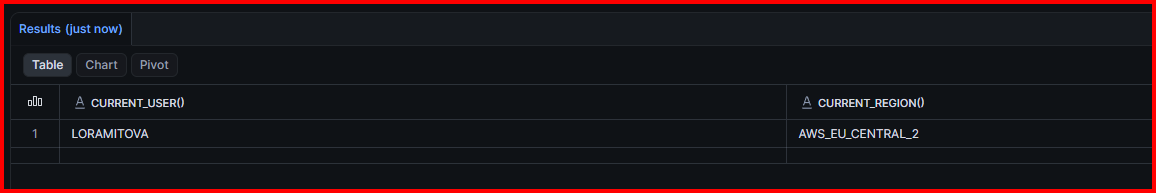

## 6. View session details (user, role, warehouse, region)

Confirm your active user, role, warehouse, and region.

In [33]:
# SELECT CURRENT_USER(), CURRENT_ROLE(), CURRENT_WAREHOUSE(), CURRENT_REGION();

![image.png](attachment:7ad8ef6e-05cf-445a-bce6-c0d0d510b9a8.png)

## 7. Display your organization, account name, and cloud provider

Discover your Snowflake organization and account-level metadata.

In [34]:
# SELECT CURRENT_ORGANIZATION_NAME(),  CURRENT_ACCOUNT_NAME(), CURRENT_REGION();
# SELECT CURRENT_ACCOUNT();

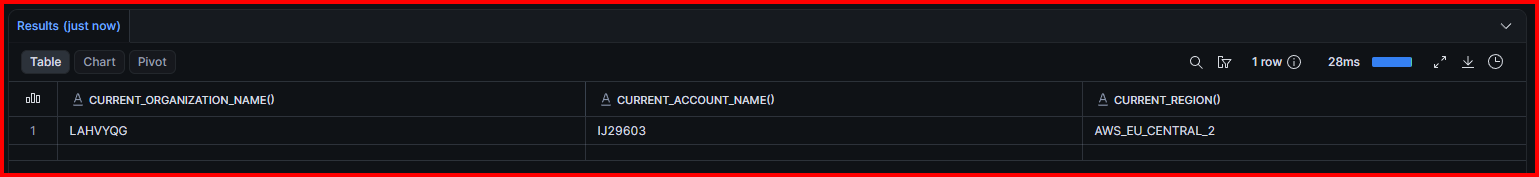
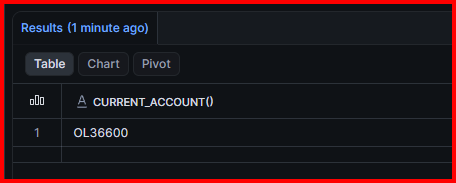

## 8. List all available warehouses and check their state

View all existing compute resources and their states.

In [35]:
# SHOW WAREHOUSES;

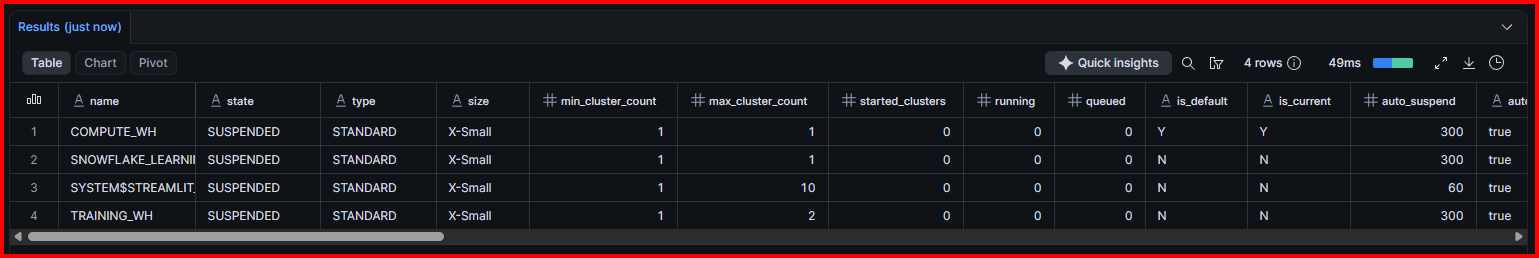

## 9. Create a compute warehouse

Provision compute to run queries and transformations.

In [36]:
# CREATE WAREHOUSE IF NOT EXISTS TRAINING_WH
# WAREHOUSE_SIZE = 'XSMALL'
# AUTO_SUSPEND=60
# AUTO_RESUME=TRUE;

# ALTER WAREHOUSE TRAINING_WH
#     SET
#         WAREHOUSE_SIZE = 'SMALL'
#         AUTO_SUSPEND=90
#     AUTO_RESUME=TRUE
#     MIN_CLUSTER_COUNT=1
#     MAX_CLUSTER_COUNT=3;


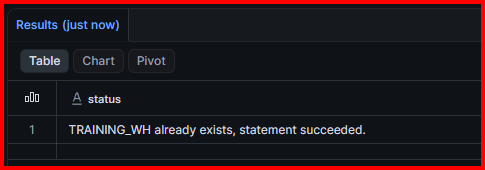

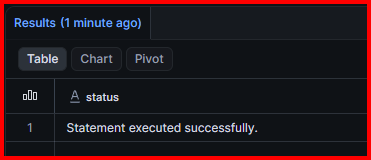

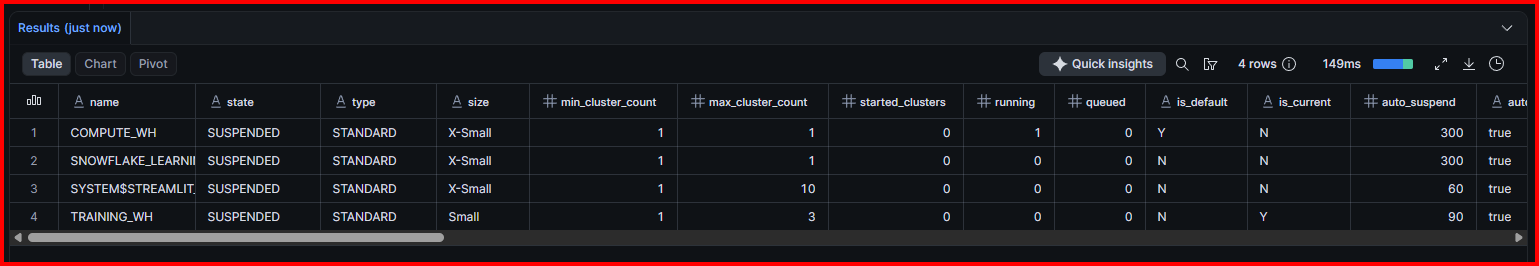

## 10. See all databases available to your role

Find which databases your current role can access.

In [37]:
# SHOW DATABASES;

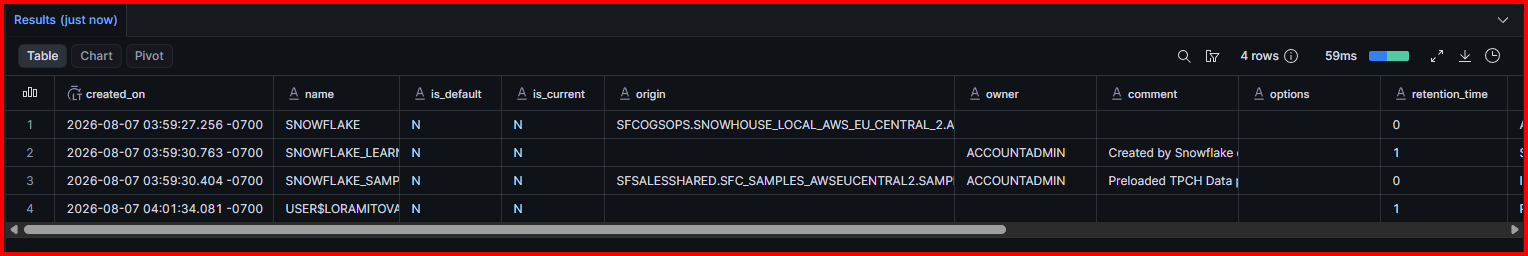

## 11. Create schemas

Design your multi-layer Snowflake schema structure.

In [38]:
# CREATE DATABASE IF NOT EXISTS SALED_ANALYTICS_DB;

# USE DATABASE SALED_ANALYTICS_DB;

# CREATE SCHEMA IF NOT EXISTS STAGING_LAYER;
# CREATE SCHEMA IF NOT EXISTS RAW_LAYER;
# CREATE SCHEMA IF NOT EXISTS CLEANSED_LAYER;
# CREATE SCHEMA IF NOT EXISTS BUSINESS_LAYER;
# CREATE SCHEMA IF NOT EXISTS PRESENTATION_LAYER;

## 12. View login history (great for audit/compliance intro)

Check who accessed Snowflake and when — great for auditing.

In [39]:
# SELECT * FROM TABLE(INFORMATION_SCHEMA.LOGIN_HISTORY())
# ORDER BY EVENT_TIMESTAMP DESC LIMIT 20;

## 13. List any currently executing queries

View currently executing workloads.

In [40]:
# SELECT * FROM TABLE(INFORMATION_SCHEMA.LOGIN_HISTORY())
# ORDER BY EVENT_TIMESTAMP DESC LIMIT 20;

# SELECT * FROM SNOWFLAKE.ACCOUNT_USAGE.LOGIN_HISTORY
# ORDER BY EVENT_TIMESTAMP DESC LIMIT 20;

# SELECT * FROM TABLE(INFORMATION_SCHEMA.QUERY_HISTORY())
# ORDER BY START_TIME DESC LIMIT 20;

# SELECT * FROM TABLE(INFORMATION_SCHEMA.QUERY_HISTORY())
# WHERE EXECUTION_STATUS ='RUNNING';

## 14. Create Database

Establish a centralized database for all sales data.

In [41]:
# CREATE DATABASE IF NOT EXISTS SALED_ANALYTICS_DB;

## 15. Create Table

Define your base transactional fact table structure.

In [42]:
# CREATE OR REPLACE TABLE RAW_LAYER.ORDER_RAW(
#     ORDER_ID STRING,
#     CUSTOMER_ID STRING,
#     PRODUCT_ID STRING,
#     ORDER_DATE STRING,
#     AMOUNT STRING,
#     PROFIT STRING,
#     QUANTITY STRING,
#     CATEGORY STRING,
#     SUBCATEGORY STRING
# );

## 16. Create a role, assign user, grant access

Secure your database and table using roles.

In [43]:
# Ingestion -> Add data -> Load data into Table
# SELECT * FROM RAW_LAYER.ORDER_RAW;

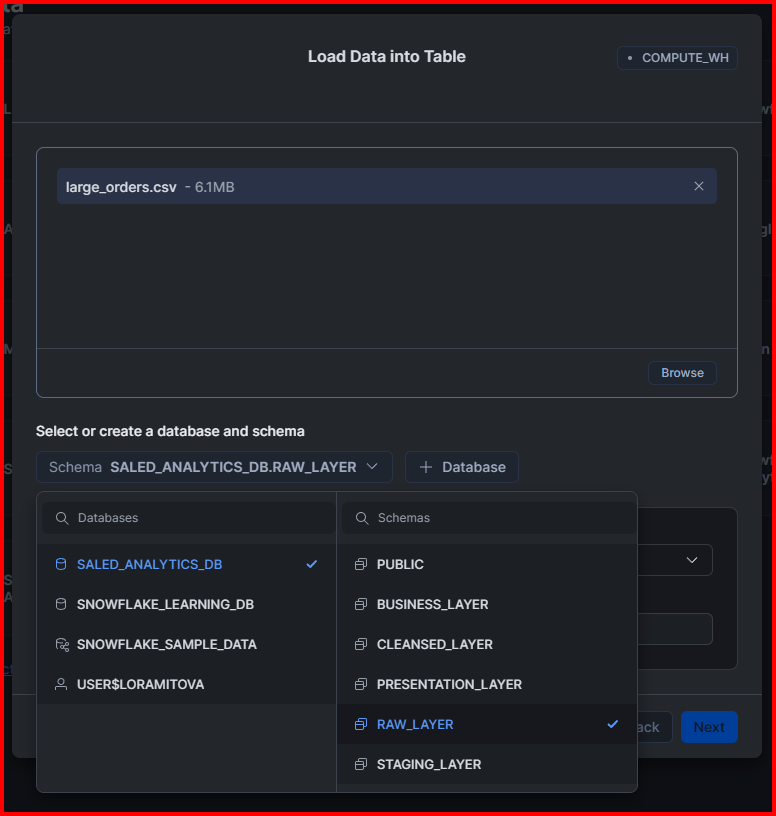
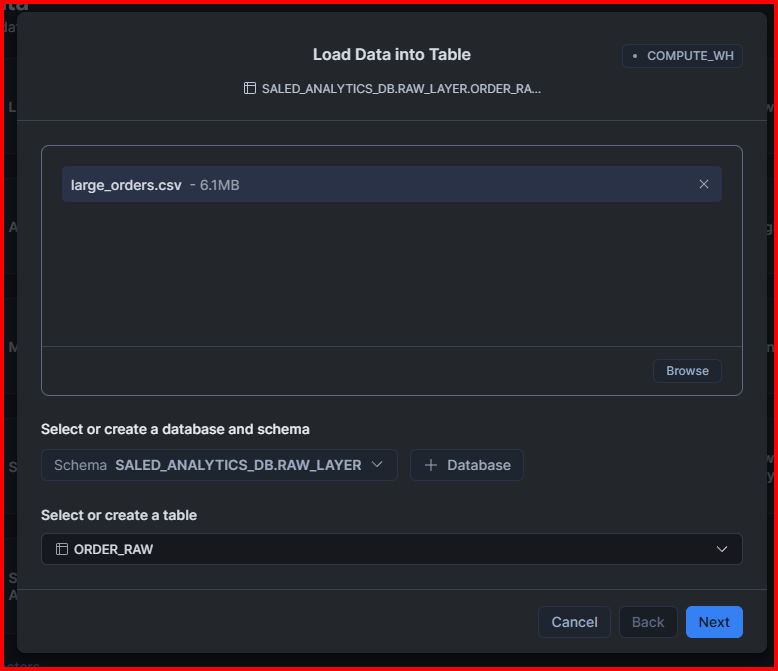
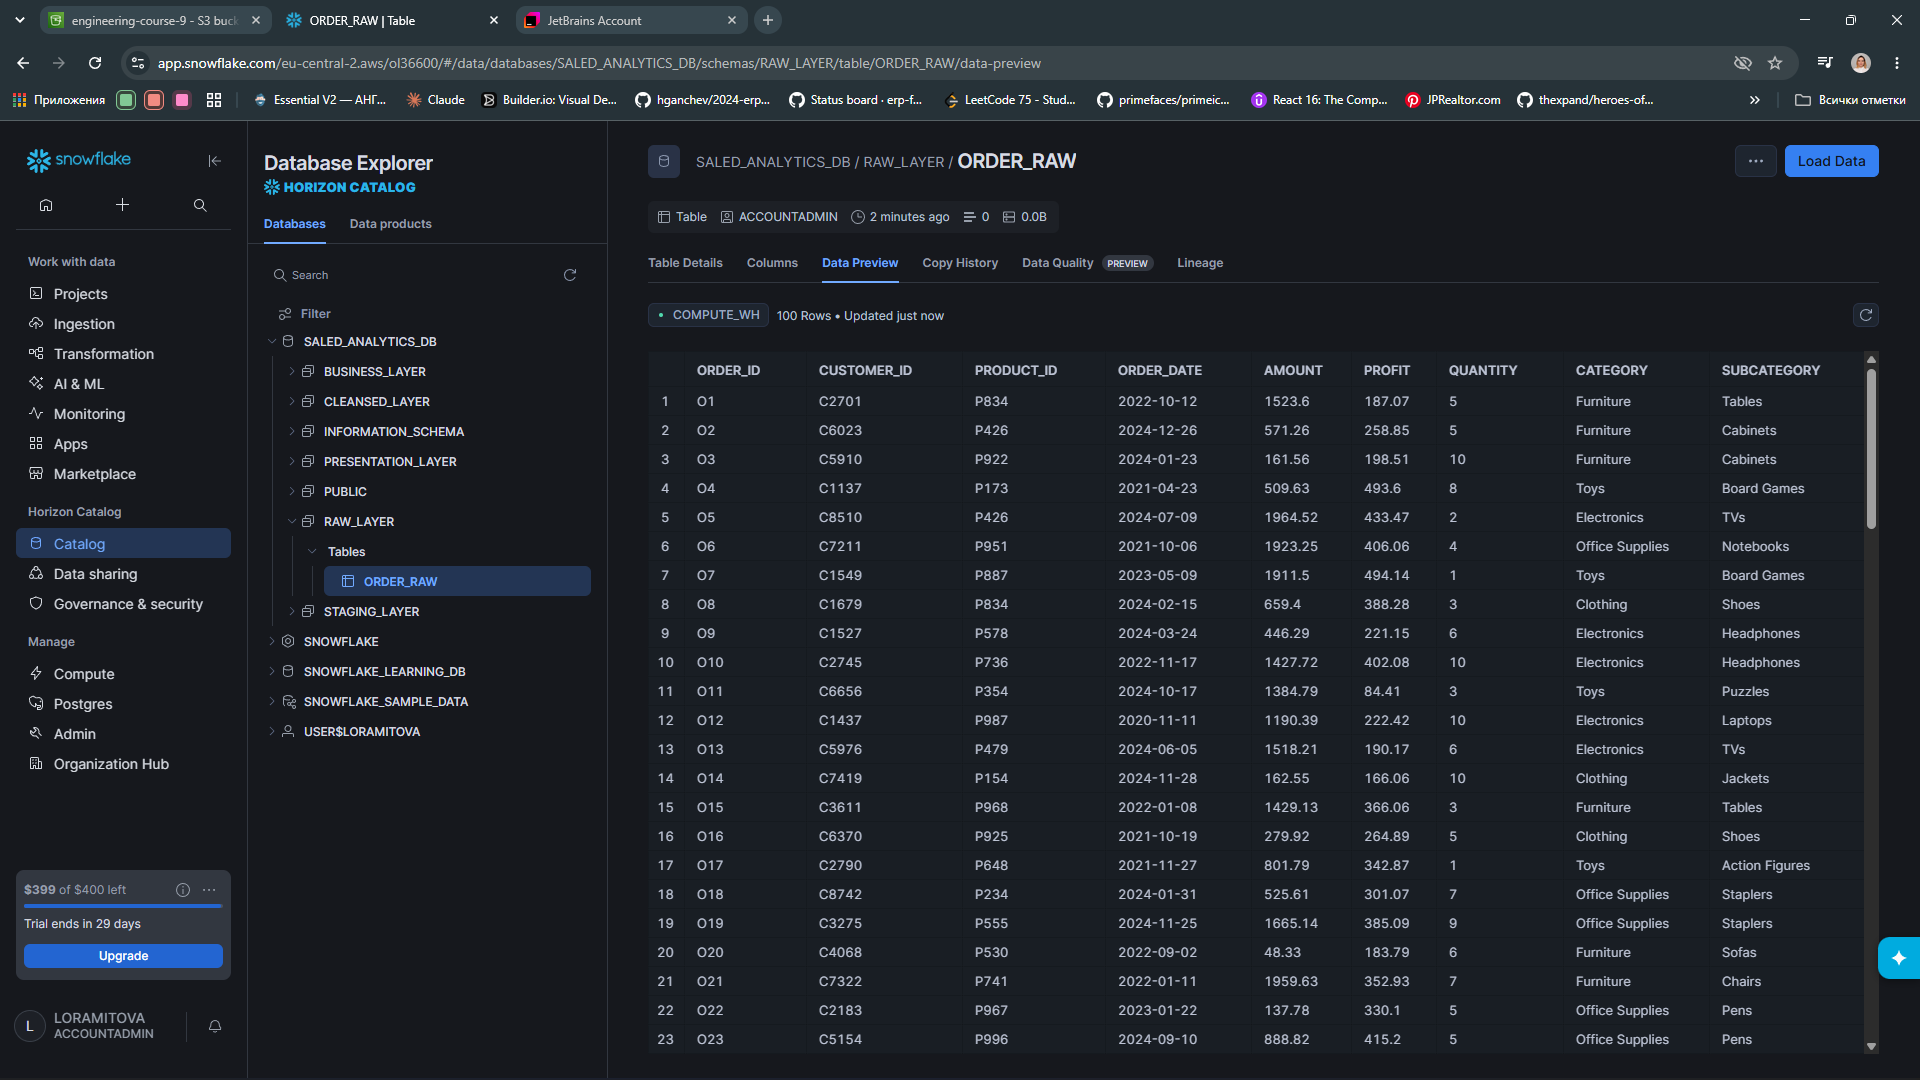
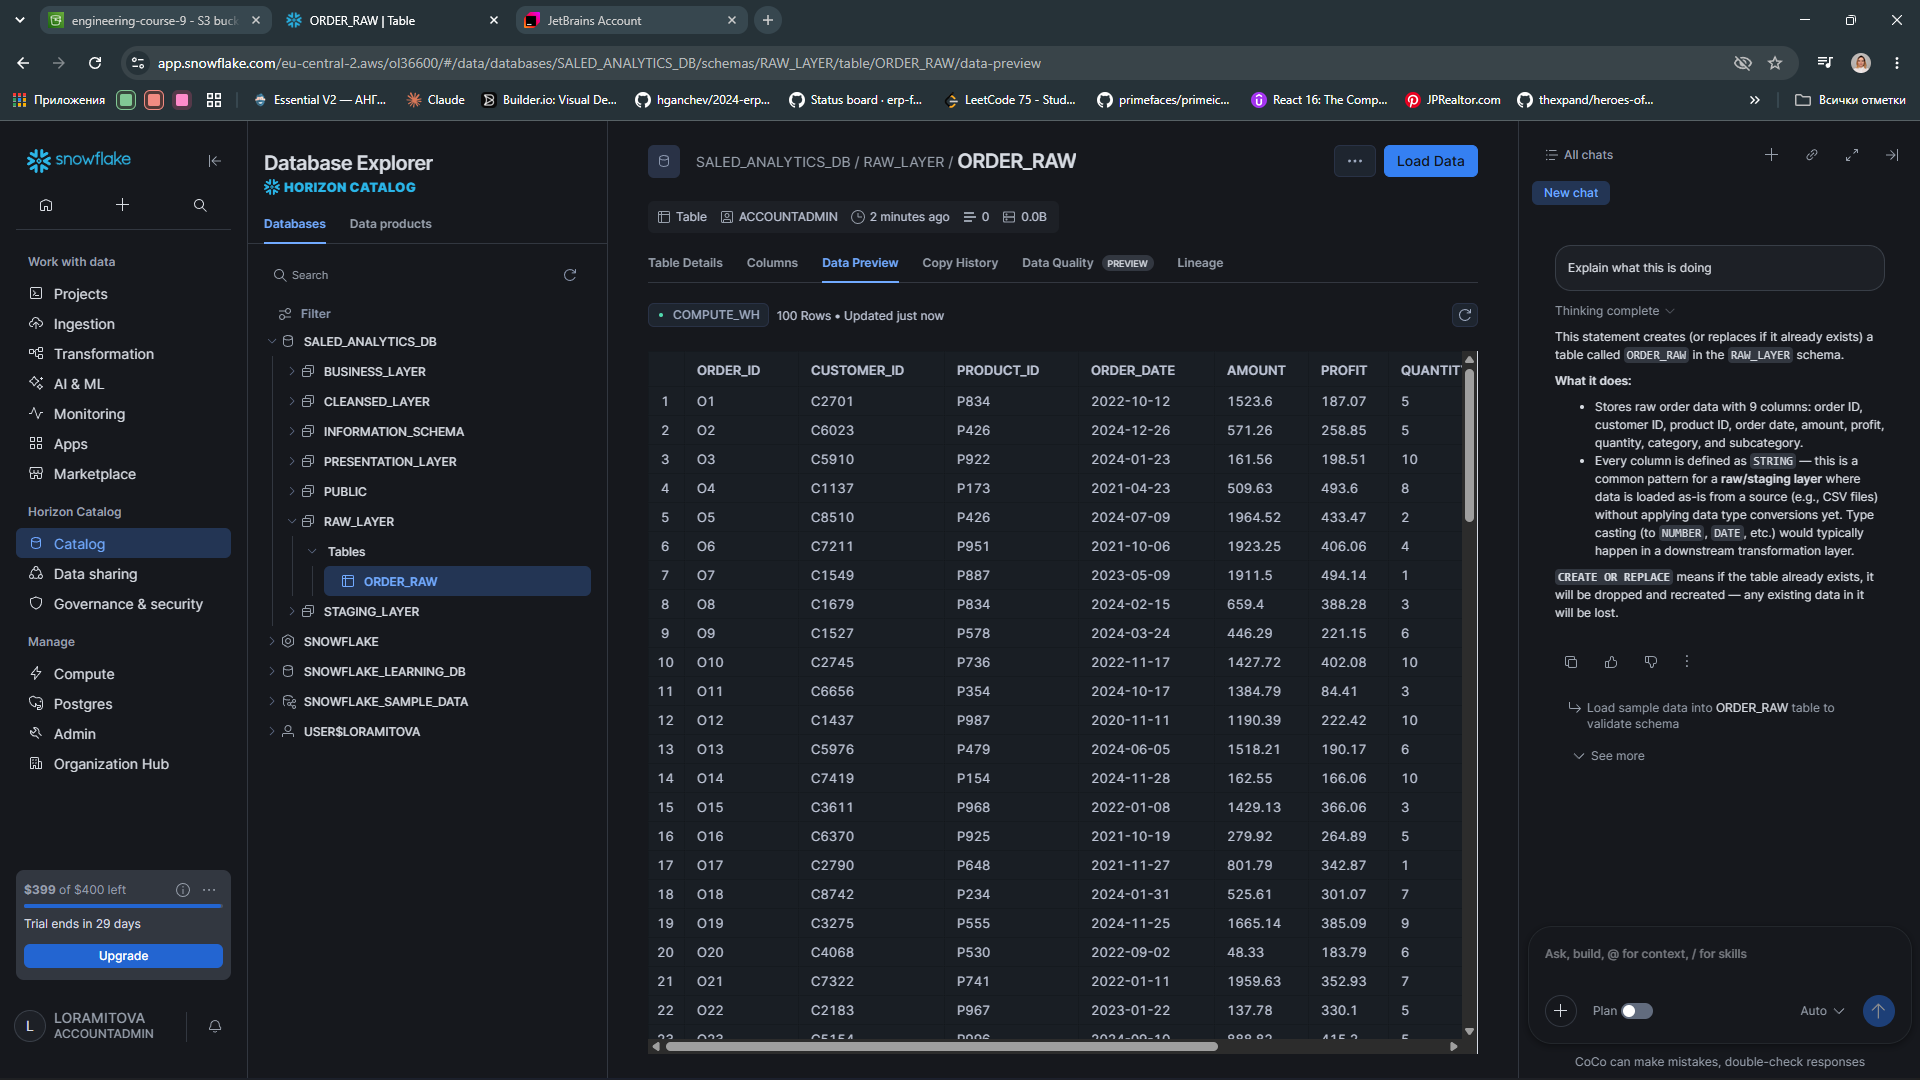

## 17. Assign Current User to role analyst_role

Simulate working as a limited-access analyst.

In [44]:
# CREATE USER ANALYST_USER_JULY
#     PASSWORD='ANALYST_USER_JULY12345'
#     MUST_CHANGE_PASSWORD= FALSE
# COMMENT = 'MY ANALYST ROLE JULY';

## 18. View Your Current Role Privileges

Understand what your role can do.

In [45]:
# CREATE ROLE IF NOT EXISTS ANALYST_ROLE;
#
# GRANT ROLE ANALYST_ROLE TO USER ANALYST_USER_JULY;
#
# GRANT USAGE ON WAREHOUSE TRAINING_WH TO ROLE ANALYST_ROLE;
#
# GRANT USAGE ON DATABASE SALES_ANALYTICS_DB TO ROLE ANALYST_ROLE;
#
# GRANT USAGE ON SCHEMA SALES_ANALYTICS_DB.STAGING_LAYER TO ROLE ANALYST_USER_JULY;
# GRANT USAGE ON SCHEMA SALES_ANALYTICS_DB.RAW_LAYER TO ROLE ANALYST_USER_JULY;
# GRANT USAGE ON SCHEMA SALES_ANALYTICS_DB.CLEANSED_LAYER TO ROLE ANALYST_USER_JULY;
# GRANT USAGE ON SCHEMA SALES_ANALYTICS_DB.BUSINESS_LAYER TO ROLE ANALYST_USER_JULY;
# GRANT USAGE ON SCHEMA SALES_ANALYTICS_DB.PRESENTATION_LAYER TO ROLE ANALYST_USER_JULY;
#
# GRANT SELECT ON ALL TABLES IN SCHEMA SALED_ANALYTICS_DB.RAW_LAYER TO ROLE ANALYST_ROLE;
# GRANT SELECT ON ALL TABLES IN SCHEMA SALED_ANALYTICS_DB.STAGING_LAYER TO ROLE ANALYST_ROLE;
# GRANT SELECT ON ALL TABLES IN SCHEMA SALED_ANALYTICS_DB.CLEANSED_LAYER TO ROLE ANALYST_ROLE;
# GRANT SELECT ON ALL TABLES IN SCHEMA SALED_ANALYTICS_DB.BUSINESS_LAYER TO ROLE ANALYST_ROLE;
# GRANT SELECT ON ALL TABLES IN SCHEMA SALED_ANALYTICS_DB.PRESENTATION_LAYER TO ROLE ANALYST_ROLE;
#
# GRANT SELECT ON FUTURE TABLES IN SCHEMA SALED_ANALYTICS_DB.RAW_LAYER TO ROLE ANALYST_ROLE;

## 19. Revert to full access

Return to high-privilege access for further administration.

In [46]:
# GRANT ROLE ANALYST_ROLE TO USER LORAMITOVA
#
# USE ROLE ANALYST_ROLE;
# SELECT CURRENT_ROLE();
#
# REVOKE USAGE ON SCHEMA SALED_ANALYTICS_DB.STAGING_LAYER FROM ROLE ANALYST_ROLE;
# REVOKE USAGE ON SCHEMA SALED_ANALYTICS_DB.RAW_LAYER FROM ROLE ANALYST_ROLE;
#
# USE ROLE ACCOUNTADMIN;